# Mochila Binária
### Kariny e Wandra


▶ Itens: i ∈ {0, 1, ..., n − 1} (índice) \
▶ Peso: p[i], Valor: v[i] (peso e utilidade)\
▶ Capacidade: c

In [371]:
TAM_POP = 100
TAXA_MUT = 0.8
NUM_GERACOES = 100
arq_c = 'p08_c.txt'
arq_p = 'p08_p.txt'
arq_w = 'p08_w.txt'
arq_s = 'p08_s.txt'

def leitura_arquivos():
  with open(arq_c, 'r', encoding='utf-8') as capacidade:
      cap = int(capacidade.read().strip())
 # print(f'Capacidade: {c}')

  util = [] # utilidade
  with open(arq_p, 'r', encoding='utf-8') as utilidade:
      for linha in utilidade:
          valor = linha.strip()
          util.append(int(valor))
  # print(f'Utilidades: {v}')

  peso = [] # pesos
  with open(arq_w, 'r', encoding='utf-8') as pesos:
      for linha in pesos:
          valor = linha.strip()
          peso.append(int(valor))
  # print(f'Pesos: {p}')

  sol = [] # solução
  with open(arq_s, 'r', encoding='utf-8') as solucao:
      for linha in solucao:
          valor = linha.strip()
          sol.append(int(valor))
  # print(f'Soluções: {s}')

  return cap, util, peso, sol


In [372]:
def fitness(capacidade, utilidade, peso, mochila):
    peso_total = 0
    utilidade_total = 0

    for i in range(len(mochila)):
        if mochila[i] == 1:
            peso_total += peso[i]
            utilidade_total += utilidade[i]

    if peso_total <= capacidade:
        return utilidade_total
    else:
        excesso = peso_total - capacidade
        return utilidade_total - (utilidade_total * excesso)


In [373]:
import random

def gerar_mochila(tam_mochila):
  mochila = []
  for i in range(tam_mochila):
    mochila.append(random.randint(0, 1))
  return mochila

# print(gerar_mochila(10))


In [374]:
def gerar_populacao_inicial(tam_mochila, cap, util, peso):
  
  populacao = []
  for x in range(TAM_POP):
    mochila = gerar_mochila(tam_mochila)
    fit = fitness(cap, util, peso, mochila)
    populacao.append((mochila, fit))

  return populacao

In [375]:
def torneio(pop, k=2): # sorteia 3
  sorteados = random.sample(pop, k)
  selecionado = max(sorteados, key=lambda ind: ind[1])
  return selecionado

In [376]:
def elitismo(pop):
  melhor = max(pop, key=lambda ind: ind[1])
  return melhor

In [377]:
def crossover(pai1, pai2, cap, util, peso):
    mochila1 = pai1[0]
    mochila2 = pai2[0]

    tam = len(mochila1)

    # ponto de corte
    ponto = random.randint(1, tam - 1)

    # filhos
    filho1 = mochila1[:ponto] + mochila2[ponto:]
    filho2 = mochila2[:ponto] + mochila1[ponto:]

    # fitness dos filhos
    fit1 = fitness(cap, util, peso, filho1)
    fit2 = fitness(cap, util, peso, filho2)

    return (filho1, fit1), (filho2, fit2)

In [378]:
def gerar_filhos(pop_inicial, cap, util, peso):
  nova_pop = []
  while len(nova_pop) < TAM_POP - 1:
    pai1 = torneio(pop_inicial)
    pai2 = torneio(pop_inicial)
    while pai1 == pai2:
      pai2 = torneio(pop_inicial)
      
    filho1, filho2 = crossover(pai1, pai2, cap, util, peso)
    nova_pop.append(filho1)
    if len(nova_pop) < TAM_POP - 1:
      nova_pop.append(filho2)
      
  return nova_pop


In [379]:
import random

def mutacao(pop, cap, util, peso):
    nova_pop = []

    for individuo in pop:
        mochila, fit = individuo
        nova_mochila = mochila.copy()

        if random.random() < TAXA_MUT:
            # escolhe 2 índices diferentes
            indices = random.sample(range(len(nova_mochila)), 2)

            for idx in indices:
                nova_mochila[idx] = 1 - nova_mochila[idx]

            # recalcula fitness
            fit = fitness(cap, util, peso, nova_mochila)

        nova_pop.append((nova_mochila, fit))

    return nova_pop

Geração Inicial: Mochila = [1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0] Fitness = 13232681
Geração 1: Mochila = [1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0] Fitness = 13232681
Geração 2: Mochila = [1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0] Fitness = 13232681
Geração 3: Mochila = [1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0] Fitness = 13232681
Geração 4: Mochila = [1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0] Fitness = 13232681
Geração 5: Mochila = [1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0] Fitness = 13232681
Geração 6: Mochila = [1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0] Fitness = 13232681
Geração 7: Mochila = [1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0] Fitness = 13232681
Geração 8: Mochila = [1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0,

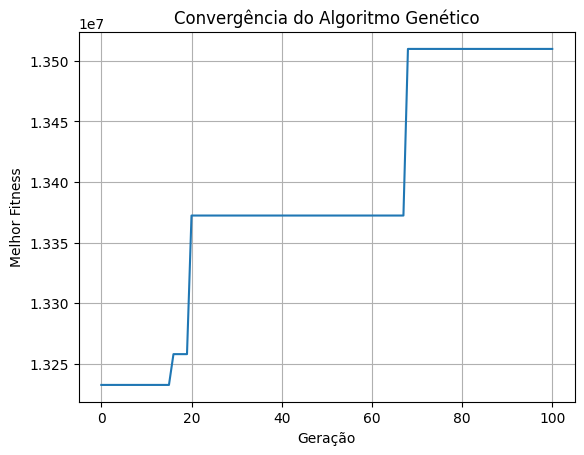

In [ ]:
import matplotlib.pyplot as plt

def main():

  cap, util, peso, sol = leitura_arquivos()
  tam_mochila = len(util) 
  
  pop = gerar_populacao_inicial(tam_mochila, cap, util, peso)

  historico = []

  melhor = max(pop, key=lambda ind: ind[1])
  historico.append(melhor[1])

  print(f"Geração Inicial: Mochila = {melhor[0]} Fitness = {melhor[1]}")
  
  for geracao in range(NUM_GERACOES):
    elite = elitismo(pop)
    pop = gerar_filhos(pop, cap, util, peso)
    pop = mutacao(pop, cap, util, peso)
    pop.append(elite)

    melhor = max(pop, key=lambda ind: ind[1])
    historico.append(melhor[1])

    print(f"Geração {geracao+1}: Mochila = {melhor[0]} Fitness = {melhor[1]}")

  # print final
  print("A melhor solução encontrada: ", melhor)
  print(f"A melhor solução é: {sol}, {fitness(cap, util, peso, sol)}")

  # GRÁFICO DE CONVERGÊNCIA
  plt.plot(historico)
  plt.title("Convergência do Algoritmo Genético")
  plt.xlabel("Geração")
  plt.ylabel("Melhor Fitness")
  plt.grid(True)
  plt.show()


  
main()